In [1]:
# ===============================
# STEP 1 : Import Libraries
# ===============================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Finance.csv")

# First 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print(df.shape)

df.info()

(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
num_cols = ["LoanAmount",
            "Loan_Amount_Term",
            "Credit_History"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [7]:
cat_cols = ["Gender",
            "Married",
            "Dependents",
            "Self_Employed"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [9]:
# Feature Engineering
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

In [10]:
df["EMI"] = (
    df["LoanAmount"] /
    df["Loan_Amount_Term"]
)

In [11]:
df["LoanIncomeRatio"] = (
    df["LoanAmount"] /
    df["TotalIncome"]
)

In [13]:
if "Loan_ID" in df.columns:
    df.drop("Loan_ID", axis=1,inplace=True)

In [14]:
df["ApplicantIncome"] = np.log1p(df["ApplicantIncome"])

df["CoapplicantIncome"] = np.log1p(df["CoapplicantIncome"])

df["LoanAmount"] = np.log1p(df["LoanAmount"])

df["TotalIncome"] = np.log1p(df["TotalIncome"])

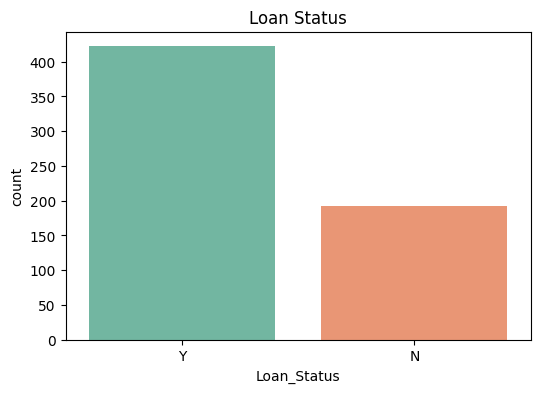

In [15]:
# Data Visualization
plt.figure(figsize=(6,4))

sns.countplot(
    x="Loan_Status",
    data=df,
    palette="Set2"
)

plt.title("Loan Status")
plt.show()

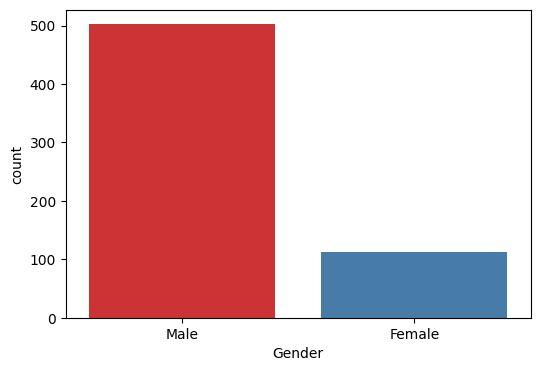

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    data=df,
    palette="Set1"
)

plt.show()

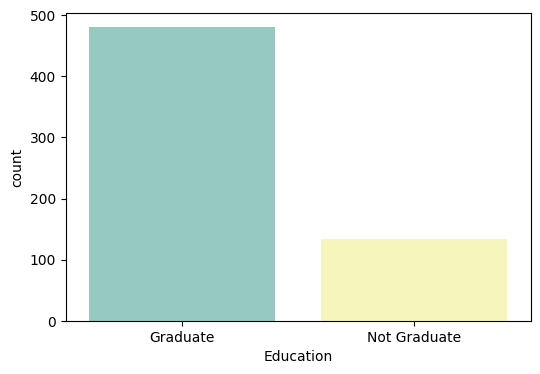

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Education",
    data=df,
    palette="Set3"
)

plt.show()

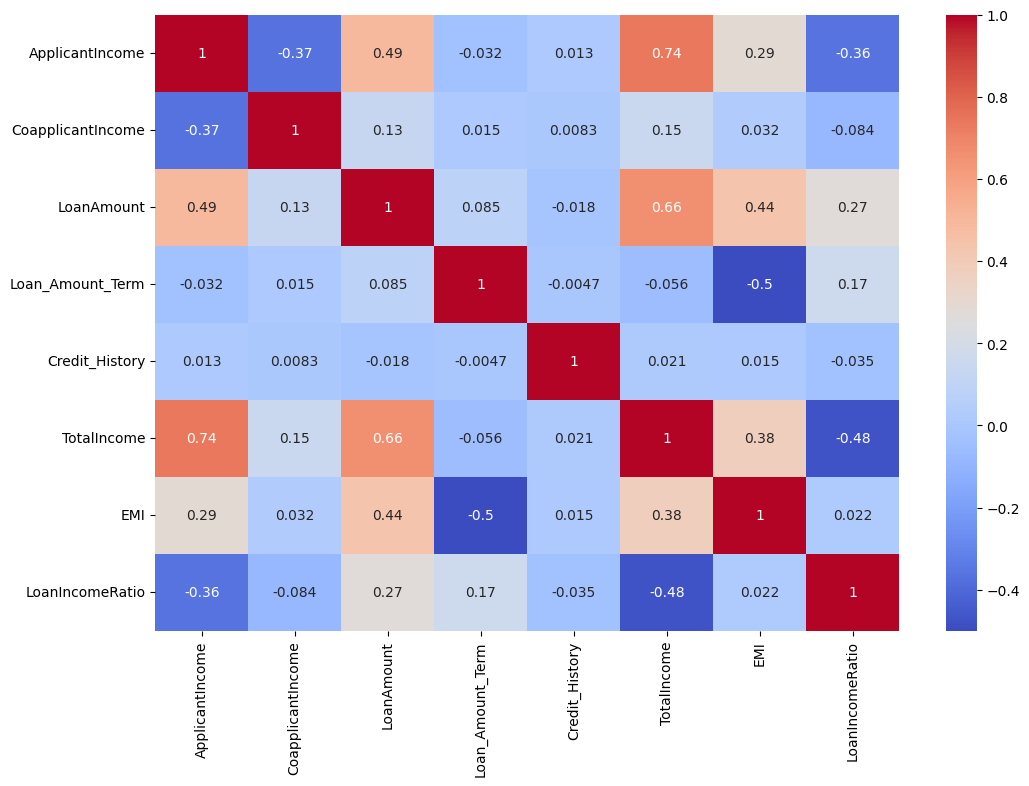

In [18]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [19]:
le = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Dependents",
    "Loan_Status"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [20]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [21]:
print(X.head())

print()

print(y.head())

   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0         8.674197   
1       1        1           1          0              0         8.430327   
2       1        1           0          0              1         8.006701   
3       1        1           0          1              0         7.857094   
4       1        0           0          0              0         8.699681   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0           0.000000    4.859812             360.0             1.0   
1           7.319202    4.859812             360.0             1.0   
2           0.000000    4.204693             360.0             1.0   
3           7.765993    4.795791             360.0             1.0   
4           0.000000    4.955827             360.0             1.0   

   Property_Area  TotalIncome       EMI  LoanIncomeRatio  
0              2     8.674197  0.355556         0.021884 

In [22]:
print(X.shape)

print(y.shape)

(614, 14)
(614,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (491, 14)
Testing Data : (123, 14)


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
y_pred = rf.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8617886178861789

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.68      0.75        38
           1       0.87      0.94      0.90        85

    accuracy                           0.86       123
   macro avg       0.85      0.81      0.83       123
weighted avg       0.86      0.86      0.86       123


Confusion Matrix

[[26 12]
 [ 5 80]]
